# SINDy vs the neural ODE at Re 36 and Re 73

Two measurements only: the growth rate at the origin, and the trajectory.

Re 73 is the limit cycle case. Re 36 is the stable one, 8 units below onset, and
the only subcritical case worth scoring against since Re 30 has no measured
growth rate and Re 41's is too close to zero for a percentage to mean anything.

SINDy fits one equation for the whole state vector `z = (a1, ..., a8)`:

$$\dot z = A z + Q(z, z)$$

`A` is one 8 by 8 matrix, `Q` holds the quadratic terms, and mode `i`'s equation
is row `i` of that system. Linear plus quadratic is not a guess: Galerkin
projection of Navier-Stokes gives exactly those two orders. There is no constant
term, so `z = 0` is an exact fixed point, which is what `f(z) = g(z) - g(0)` does
in the neural ODE. Fitting is plain least squares over 44 candidate columns.

- `sigma` is the leading oscillatory eigenvalue of `A` alone, the Jacobian at the
  origin. For the neural ODE it is the same quantity by finite differences.
- trajectories are integrated with the same RK4 stepper and time step for both.

Both models are fitted on ONE Reynolds number at a time, so neither sees data the
other does not. The mode count differs because it suits them differently: SINDy
is best at 8, the neural ODE at 14. Forcing SINDy to 14 takes it from 43% error
to 689% at Re 73.

In [1]:
from pathlib import Path
import pickle

import numpy as np
import matplotlib.pyplot as plt
from IPython.display import Markdown, display

DATA = Path('../data')
DT = 0.399
TARGETS = [36.0, 73.0]
MEASURED = {36.0: -0.04589, 73.0: 0.09030}

FITS = pickle.load(open('sindy_fits.pkl', 'rb'))
d16 = np.load(DATA / 'latent_r16.npz')
LABEL = {2: 'outward', 3: 'inward', 20: 'outward', 21: 'inward'}


def truth(Re, r):
    m = d16['Re'] == float(Re)
    return d16['a'][m][:, :r].astype(float), d16['traj'][m]


def err(s, Re):
    return 100 * abs(s - MEASURED[Re]) / abs(MEASURED[Re])


def rms(pred, tru):
    m = np.all(np.isfinite(pred), axis=1)
    if m.sum() < 2:
        return np.inf, int(m.sum())
    return float(np.sqrt(np.mean((pred[m] - tru[m]) ** 2))), int(m.sum())


def table(header, align, rows, caption=None):
    md_ = ('| ' + ' | '.join(header) + ' |\n|' + '|'.join(align) + '|\n'
           + '\n'.join('| ' + ' | '.join(r) + ' |' for r in rows))
    display(Markdown(md_ + (f'\n\n{caption}' if caption else '')))


MODELS = [
    ('SINDy, 8 modes',       'tab:red',  dict(lw=2.0, ls='-')),
    ('NODE, 14 modes, 100k', 'tab:blue', dict(lw=2.0, ls='-')),
]
STYLE = {n: (c, kw) for n, c, kw in MODELS}


def entry(Re, name, tj=None):
    if name.startswith('SINDy'):
        r = FITS[('sindy_local', 8, Re, 2)]
        return r['sigma'], (r['roll'][tj] if tj is not None else None), 8
    r = FITS[('node', Re, 14, 100000, 1)]
    return r['sigma'], (r['roll'][tj] if tj is not None else None), 14

## 1. Growth rate

| Re | model | sigma | measured | error | St |  |
|---:|:---|---:|---:|---:|---:|:---|
| 36 | SINDy, 8 modes | +0.04763 | -0.04589 | 204% | 0.1142 | WRONG SIGN |
| 36 | NODE, 14 modes, 100k | -0.04790 | -0.04589 | 4% | 0.1112 | ok |
| 73 | SINDy, 8 modes | +0.12962 | +0.09030 | 44% | 0.1355 | ok |
| 73 | NODE, 14 modes, 100k | +0.12941 | +0.09030 | 43% | 0.1354 | ok |

St is |Im lambda| / 2 pi of the same eigenvalue.  It should sit near the measured shedding value of 0.13.

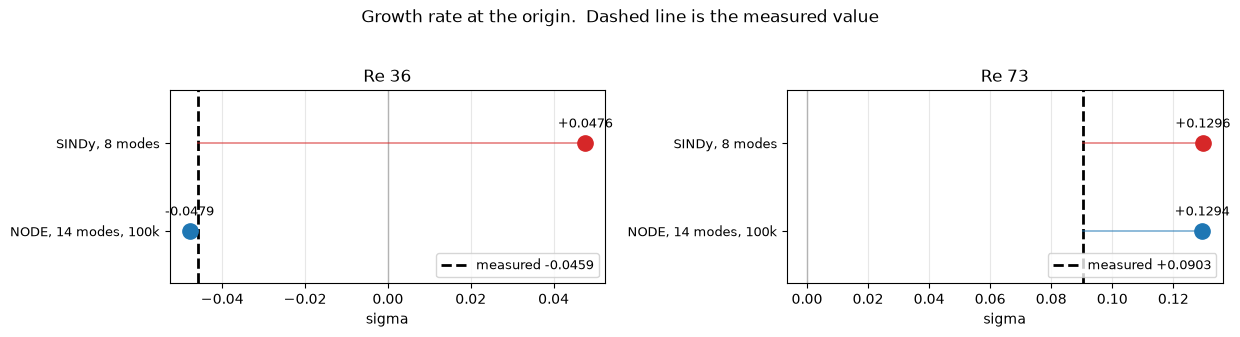

In [2]:
rows = []
for Re in TARGETS:
    for name, _, _ in MODELS:
        (s, st), _, _ = entry(Re, name)
        rows.append([f'{Re:g}', name, f'{s:+.5f}', f'{MEASURED[Re]:+.5f}',
                     f'{err(s, Re):.0f}%', f'{st:.4f}',
                     'ok' if s * MEASURED[Re] > 0 else 'WRONG SIGN'])
table(['Re', 'model', 'sigma', 'measured', 'error', 'St', ''],
      ['---:', ':---', '---:', '---:', '---:', '---:', ':---'], rows,
      caption='St is |Im lambda| / 2 pi of the same eigenvalue.  It should sit '
              'near the measured shedding value of 0.13.')

fig, axes = plt.subplots(1, 2, figsize=(12.5, 3.2))
for ax, Re in zip(axes, TARGETS):
    names = [n for n, _, _ in MODELS]
    vals = [entry(Re, n)[0][0] for n in names]
    y = np.arange(len(names))[::-1]
    ax.axvline(MEASURED[Re], color='k', ls='--', lw=2,
               label=f'measured {MEASURED[Re]:+.4f}')
    ax.axvline(0, color='0.7', lw=1)
    for yy, n, v in zip(y, names, vals):
        c = STYLE[n][0]
        ax.plot([MEASURED[Re], v], [yy, yy], color=c, lw=1.4, alpha=0.5)
        ax.plot(v, yy, 'o', color=c, ms=11)
        ax.annotate(f'{v:+.4f}', (v, yy), textcoords='offset points',
                    xytext=(0, 11), ha='center', fontsize=9)
    ax.set_yticks(y)
    ax.set_yticklabels(names, fontsize=9)
    ax.set_xlabel('sigma')
    ax.set_title(f'Re {Re:g}')
    ax.set_ylim(-0.6, len(names) - 0.4)
    ax.legend(fontsize=9, loc='lower right')
    ax.grid(alpha=0.3, axis='x')
fig.suptitle('Growth rate at the origin.  Dashed line is the measured value', y=1.04)
fig.tight_layout()
plt.show()

At Re 73 the two are level, +0.1296 against +0.1294, both about 43% high, and
both pick out the shedding mode correctly.

At Re 36 they separate. The neural ODE gets the stable case to 4%. SINDy reports
a growing mode for a flow that visibly decays, and no weighting fixes it: across
the weighting sweep its answer moves from +0.034 to +0.127 and never goes
negative.

## 2. Trajectory

In [3]:
rows = []
for Re in TARGETS:
    a8, tj8 = truth(Re, 8)
    a14, _ = truth(Re, 14)
    for tj in sorted(set(tj8.tolist())):
        for name, _, _ in MODELS:
            _, pred, r = entry(Re, name, tj)
            tru = (a8 if r == 8 else a14)[tj8 == tj]
            v, n = rms(pred, tru)
            rows.append([f'{Re:g}', LABEL[tj], name,
                         'diverged' if not np.isfinite(v) else f'{v:.4f}',
                         f'{n}/{len(tru)}'])
table(['Re', 'run', 'model', 'RMS', 'steps completed'],
      ['---:', ':---', ':---', '---:', '---:'], rows,
      caption='RMS covers only the steps a model survived, so one that diverges '
              'early can post a small number.  Read it with the last column.')

| Re | run | model | RMS | steps completed |
|---:|:---|:---|---:|---:|
| 36 | outward | SINDy, 8 modes | 0.0404 | 60/428 |
| 36 | outward | NODE, 14 modes, 100k | 0.0015 | 428/428 |
| 36 | inward | SINDy, 8 modes | 0.3730 | 12/175 |
| 36 | inward | NODE, 14 modes, 100k | 0.0019 | 175/175 |
| 73 | outward | SINDy, 8 modes | 0.0963 | 55/349 |
| 73 | outward | NODE, 14 modes, 100k | 0.1075 | 349/349 |
| 73 | inward | SINDy, 8 modes | 0.1027 | 12/175 |
| 73 | inward | NODE, 14 modes, 100k | 0.0033 | 175/175 |

RMS covers only the steps a model survived, so one that diverges early can post a small number.  Read it with the last column.

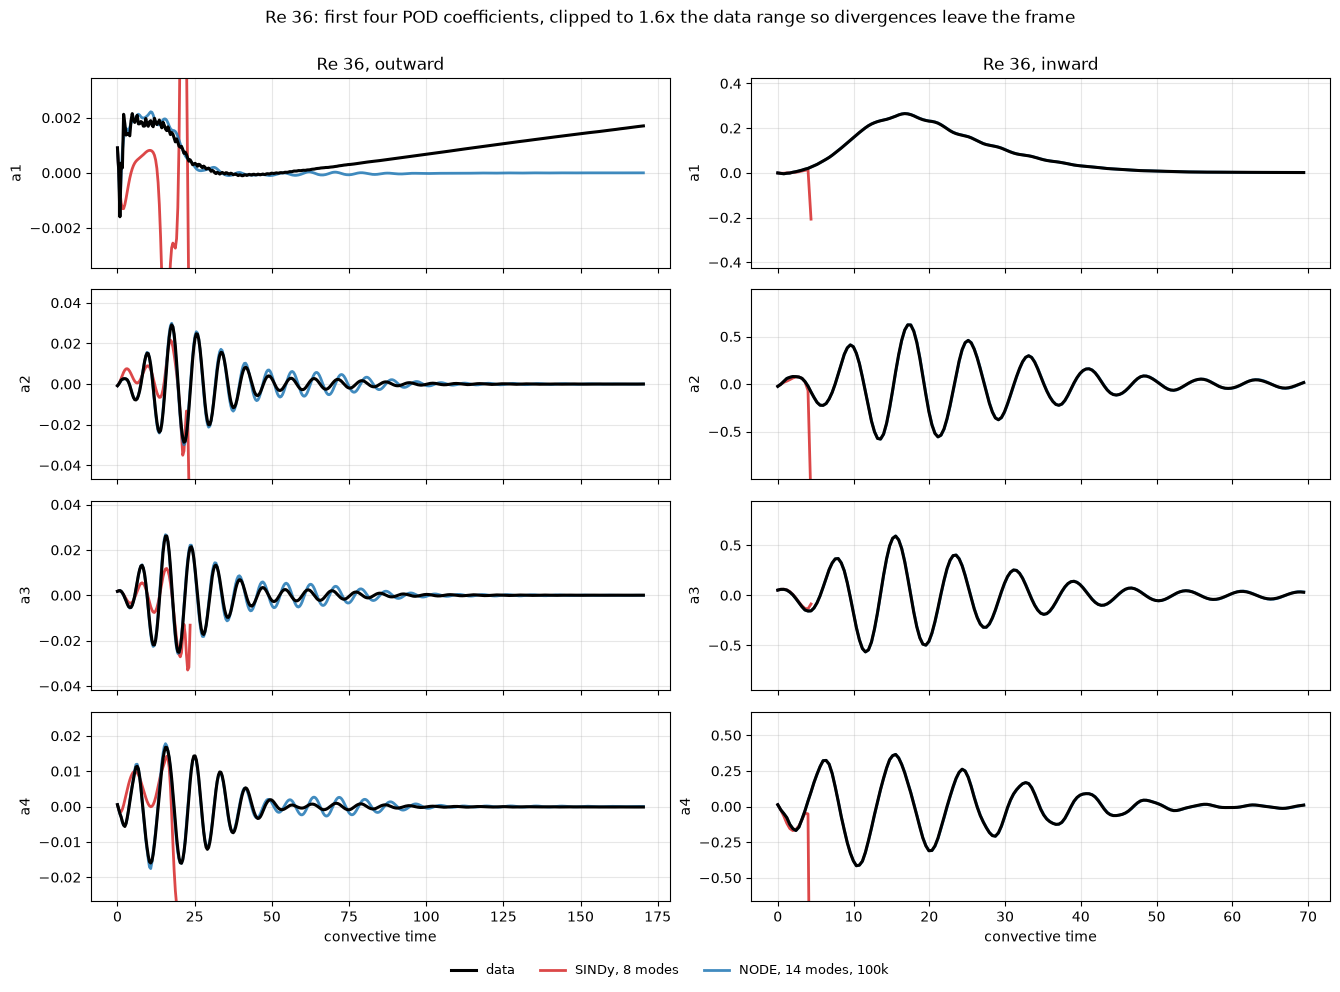

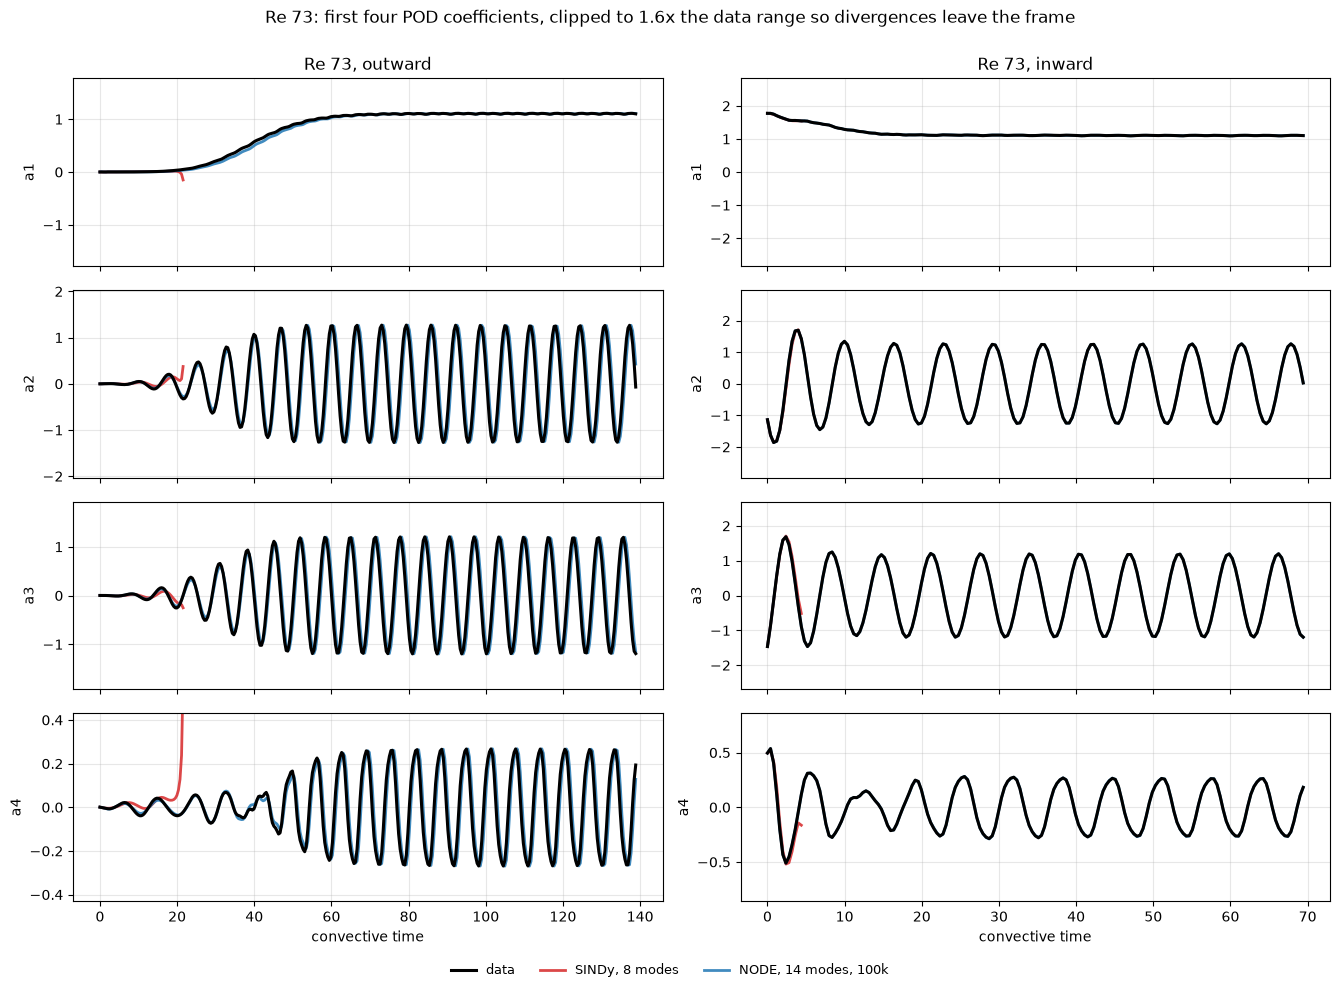

In [4]:
for Re in TARGETS:
    a8, tj8 = truth(Re, 8)
    tjs = sorted(set(tj8.tolist()))
    fig, axes = plt.subplots(4, 2, figsize=(13.5, 9.5), sharex='col')
    for col, tj in enumerate(tjs):
        m = tj8 == tj
        t = np.arange(m.sum()) * DT
        for k in range(4):
            ax = axes[k, col]
            ax.plot(t, a8[m][:, k], color='k', lw=2.2, label='data', zorder=5)
            for name, _, _ in MODELS:
                _, pred, _ = entry(Re, name, tj)
                c, kw = STYLE[name]
                y = pred[:, k].copy()
                y[~np.all(np.isfinite(pred), axis=1)] = np.nan
                ax.plot(t[:len(y)], y, color=c, label=name, alpha=0.85, **kw)
            lim = 1.6 * np.abs(a8[m][:, k]).max()
            ax.set_ylim(-lim, lim)
            ax.set_ylabel(f'a{k + 1}')
            ax.grid(alpha=0.3)
            if k == 0:
                ax.set_title(f'Re {Re:g}, {LABEL[tj]}')
            if k == 3:
                ax.set_xlabel('convective time')
    h, lab = axes[0, 0].get_legend_handles_labels()
    fig.legend(h, lab, loc='lower center', ncol=3, fontsize=9,
               bbox_to_anchor=(0.5, -0.03), frameon=False)
    fig.suptitle(f'Re {Re:g}: first four POD coefficients, clipped to 1.6x the '
                 f'data range so divergences leave the frame', y=1.00)
    fig.tight_layout()
    plt.show()

The neural ODE completes every run at both Reynolds numbers, tracking the Re 36
decay to an RMS near 0.002 and sitting on the Re 73 limit cycle for the whole
run.

SINDy survives none of the four. It gets 60 of 428 steps at Re 36 and 55 of 349
at Re 73 before running off. It places a positive eigenvalue where there should
not be one, so nothing holds the trajectory in and the quadratic term accelerates
the escape rather than saturating it.

The large RMS on the Re 73 outward run is mostly phase rather than amplitude: the
trajectory oscillates on the limit cycle for most of its length, so a small
frequency error accumulates while the envelope stays right.

## 3. Cubic SINDy

The same two measurements with one change: the library gains every cubic term
`z_i z_j z_k`, taking it from 44 columns to 164. Weighting, data, solver and
Reynolds numbers are otherwise identical, so only the library differs.

| Re | model | sigma | error | steps completed, out / in |
|---:|:---|---:|---:|---:|
| 36 | SINDy, quadratic | +0.04763 | 204% | 60/428 / 12/175 |
| 36 | SINDy, cubic | +0.17562 | 483% | 30/428 / 4/175 |
| 36 | NODE, 14 modes, 100k | -0.04790 | 4% | 428/428 / 175/175 |
| 73 | SINDy, quadratic | +0.12962 | 44% | 55/349 / 12/175 |
| 73 | SINDy, cubic | +0.28826 | 219% | 32/349 / 1/175 |
| 73 | NODE, 14 modes, 100k | +0.12941 | 43% | 349/349 / 175/175 |

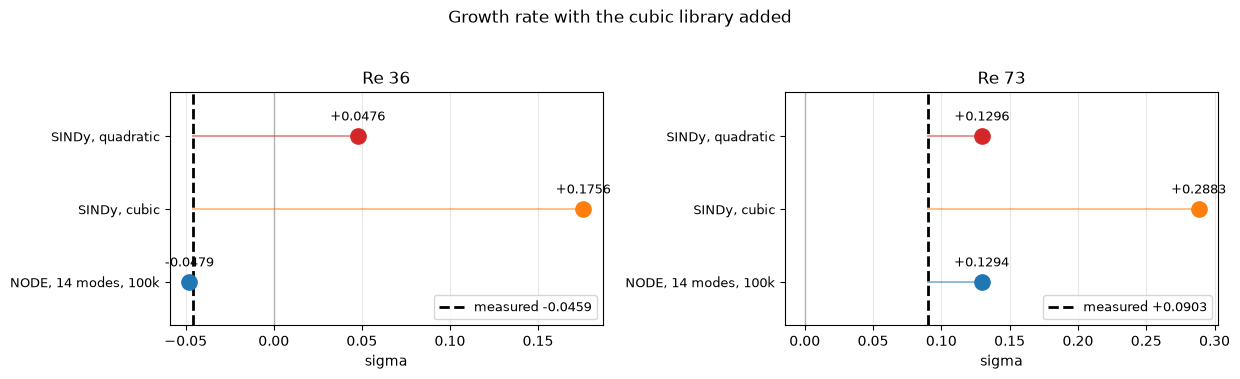

In [5]:
COMP3 = [('SINDy, quadratic', 'tab:red',   dict(lw=1.8, ls='--')),
         ('SINDy, cubic',     'tab:orange', dict(lw=2.0, ls='-')),
         ('NODE, 14 modes, 100k', 'tab:blue', dict(lw=2.0, ls='-'))]
STYLE3 = {n: (c, kw) for n, c, kw in COMP3}


def entry3(Re, name, tj=None):
    if name == 'SINDy, quadratic':
        r = FITS[('sindy_local', 8, Re, 2)]
    elif name == 'SINDy, cubic':
        r = FITS[('sindy_cubic', 8, Re, 2)]
    else:
        r = FITS[('node', Re, 14, 100000, 1)]
        return r['sigma'], (r['roll'][tj] if tj is not None else None), 14
    return r['sigma'], (r['roll'][tj] if tj is not None else None), 8


rows = []
for Re in TARGETS:
    a8, tj8 = truth(Re, 8)
    a14, _ = truth(Re, 14)
    for name, _, _ in COMP3:
        (s_, _), _, r_ = entry3(Re, name)
        surv = []
        for tj in sorted(set(tj8.tolist())):
            _, pred, _ = entry3(Re, name, tj)
            tru = (a8 if r_ == 8 else a14)[tj8 == tj]
            surv.append(f'{rms(pred, tru)[1]}/{len(tru)}')
        rows.append([f'{Re:g}', name, f'{s_:+.5f}', f'{err(s_, Re):.0f}%',
                     ' / '.join(surv)])
table(['Re', 'model', 'sigma', 'error', 'steps completed, out / in'],
      ['---:', ':---', '---:', '---:', '---:'], rows)

fig, axes = plt.subplots(1, 2, figsize=(12.5, 3.6))
for ax, Re in zip(axes, TARGETS):
    names = [n for n, _, _ in COMP3]
    vals = [entry3(Re, n)[0][0] for n in names]
    y = np.arange(len(names))[::-1]
    ax.axvline(MEASURED[Re], color='k', ls='--', lw=2,
               label=f'measured {MEASURED[Re]:+.4f}')
    ax.axvline(0, color='0.7', lw=1)
    for yy, n, v in zip(y, names, vals):
        c = STYLE3[n][0]
        ax.plot([MEASURED[Re], v], [yy, yy], color=c, lw=1.4, alpha=0.5)
        ax.plot(v, yy, 'o', color=c, ms=11)
        ax.annotate(f'{v:+.4f}', (v, yy), textcoords='offset points',
                    xytext=(0, 11), ha='center', fontsize=9)
    ax.set_yticks(y)
    ax.set_yticklabels(names, fontsize=9)
    ax.set_xlabel('sigma')
    ax.set_title(f'Re {Re:g}')
    ax.set_ylim(-0.6, len(names) - 0.4)
    ax.legend(fontsize=9, loc='lower right')
    ax.grid(alpha=0.3, axis='x')
fig.suptitle('Growth rate with the cubic library added', y=1.04)
fig.tight_layout()
plt.show()

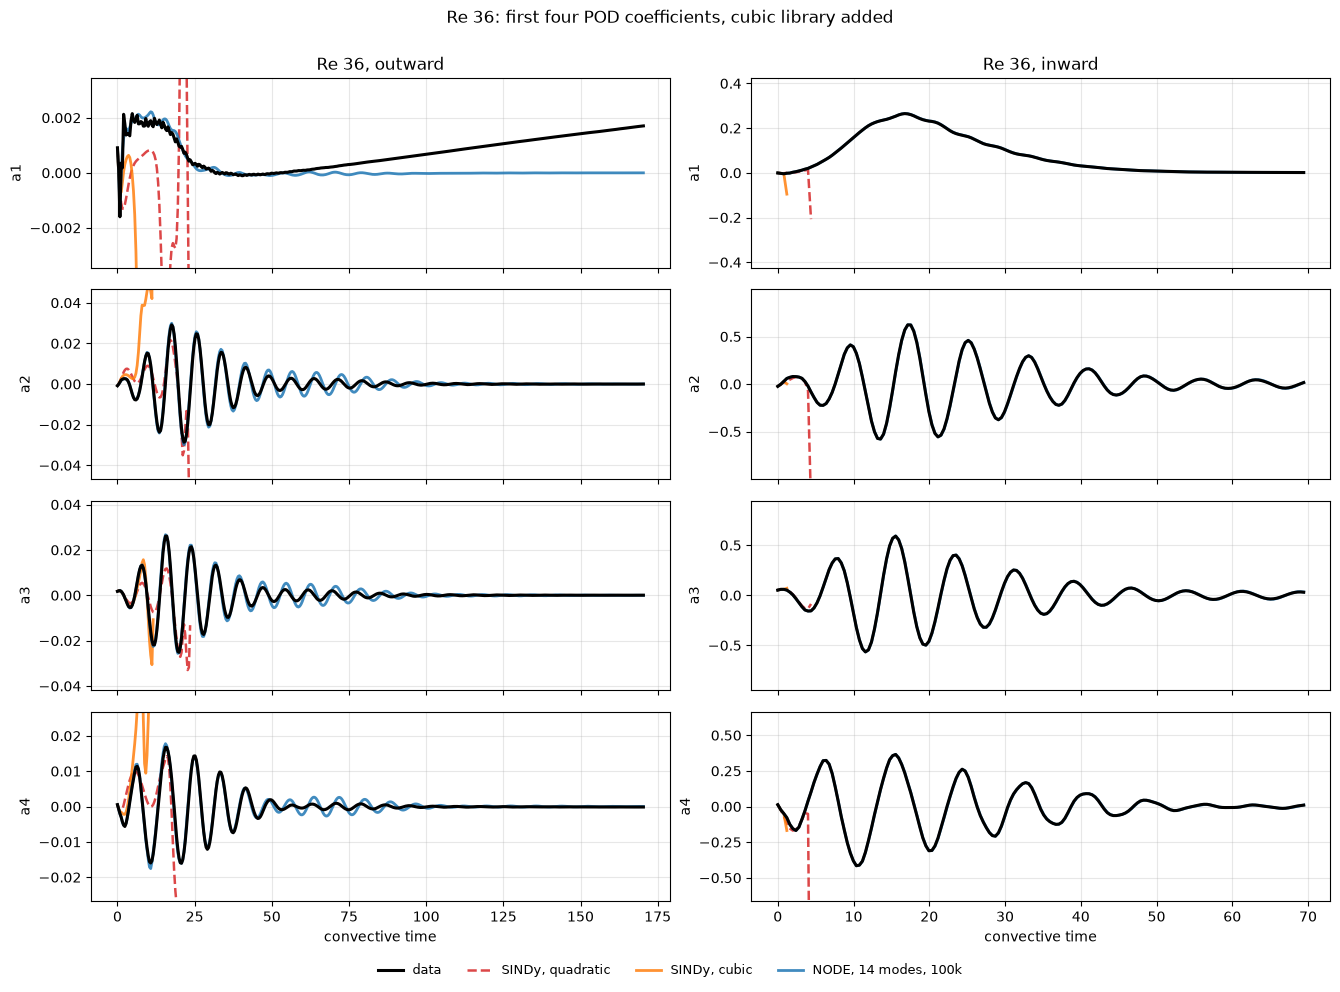

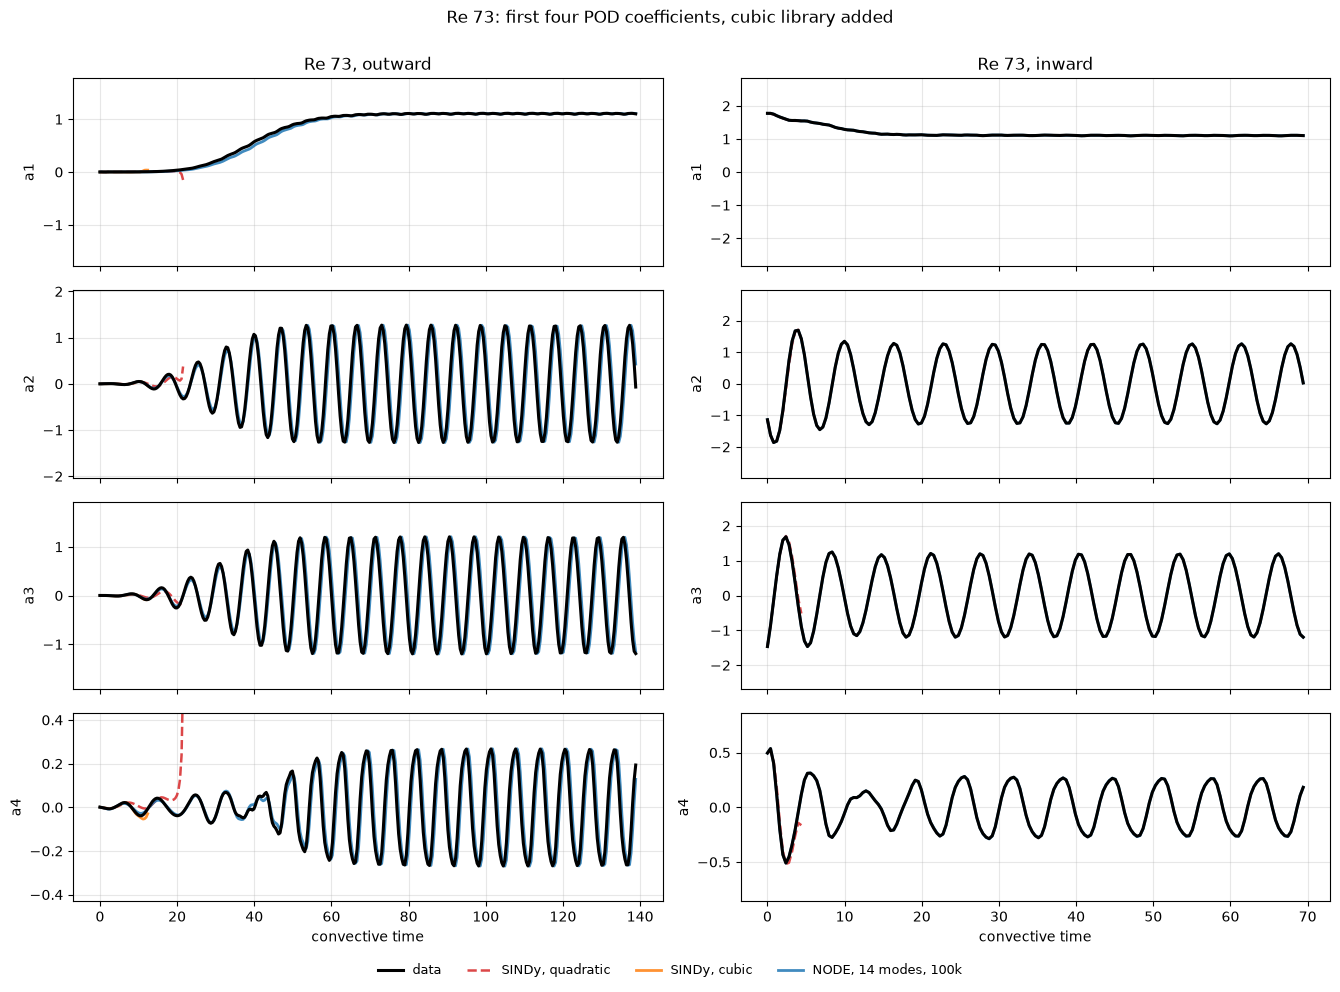

In [6]:
for Re in TARGETS:
    a8, tj8 = truth(Re, 8)
    fig, axes = plt.subplots(4, 2, figsize=(13.5, 9.5), sharex='col')
    for col, tj in enumerate(sorted(set(tj8.tolist()))):
        m = tj8 == tj
        t = np.arange(m.sum()) * DT
        for k in range(4):
            ax = axes[k, col]
            ax.plot(t, a8[m][:, k], color='k', lw=2.2, label='data', zorder=5)
            for name, _, _ in COMP3:
                _, pred, _ = entry3(Re, name, tj)
                c, kw = STYLE3[name]
                y = pred[:, k].copy()
                y[~np.all(np.isfinite(pred), axis=1)] = np.nan
                ax.plot(t[:len(y)], y, color=c, label=name, alpha=0.85, **kw)
            lim = 1.6 * np.abs(a8[m][:, k]).max()
            ax.set_ylim(-lim, lim)
            ax.set_ylabel(f'a{k + 1}')
            ax.grid(alpha=0.3)
            if k == 0:
                ax.set_title(f'Re {Re:g}, {LABEL[tj]}')
            if k == 3:
                ax.set_xlabel('convective time')
    h, lab = axes[0, 0].get_legend_handles_labels()
    fig.legend(h, lab, loc='lower center', ncol=4, fontsize=9,
               bbox_to_anchor=(0.5, -0.03), frameon=False)
    fig.suptitle(f'Re {Re:g}: first four POD coefficients, cubic library added',
                 y=1.00)
    fig.tight_layout()
    plt.show()

Cubic is worse on both counts. The growth rate goes from 44% to 219% at Re 73 and
from 204% to 483% at Re 36, and the trajectory falls over sooner, 32 of 349 steps
against 55 at Re 73. That holds across weightings: cubic's best is 85% at Re 73
and 248% at Re 36, both still behind the quadratic fit.

The extra 120 columns are the problem rather than the extra flexibility. They are
strongly correlated with the linear ones along a trajectory that lives near a low
dimensional surface, so the split between the linear part and the rest gets less
determined, and `sigma` depends only on the linear part.

## Summary

| | growth rate | trajectory |
|:---|:---|:---|
| NODE, 14 modes, 100k | 4% at Re 36, 43% at Re 73 | completes all four runs |
| SINDy, quadratic | wrong sign at Re 36, 43% at Re 73 | diverges on all four |
| SINDy, cubic | wrong sign at Re 36, 219% at Re 73 | diverges on all four, sooner |

At Re 73 the two methods are level on the growth rate. At Re 36 only the neural
ODE gets the sign right, and it is the only one of the two that can be integrated
at all.